<a href="https://colab.research.google.com/github/apolyakov320/taxi-trips-analysis/blob/main/06_07_2026_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%D0%B0_%D0%BF%D0%BE%D0%B5%D0%B7%D0%B4%D0%BE%D0%BA_%D0%BD%D0%B0_%D1%82%D0%B0%D0%BA%D1%81%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Подключение библиотек

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Загрузка и просмотр данных

In [ ]:
df = pd.read_excel('Датасет_такси.xlsx')
df.head()

,order_gk,weekday_key,hour_key,distance_km,offer_class_group,driver_response
0,412,7,22.967881,53.113626,Premium,1
1,436,3,19.439948,5.781342,Delivery,1
2,1327,6,19.816643,16.200071,Delivery,0
3,2013,2,19.123837,13.731643,Delivery,0
4,2241,6,23.164958,20.436380,Premium,1


Описательная статистика

In [ ]:
df.describe()

,order_gk,weekday_key,hour_key,distance_km,driver_response
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,462807.384000,4.044000,21.520472,26.275849,0.587000
std,270556.211847,2.007256,4.355491,18.876337,0.492496
min,412.000000,1.000000,14.899553,0.024259,0.000000
25%,227126.500000,2.000000,18.466897,12.176830,0.000000
50%,458637.000000,4.000000,20.414741,22.828544,1.000000
75%,709420.250000,6.000000,23.497139,36.434558,1.000000
max,919196.000000,7.000000,50.206056,138.950082,1.000000


Формирование выборки по классу

In [ ]:
df_1 = df[df['offer_class_group'] == 'Economy']
df_2 = df[df['offer_class_group'] == 'Comfort']

print('Выборки имеют одинаковую длину: ', len(df_1) == len(df_2))

Выборки имеют одинаковую длину:  True


Визуализация плотности распределения дистанций поездок

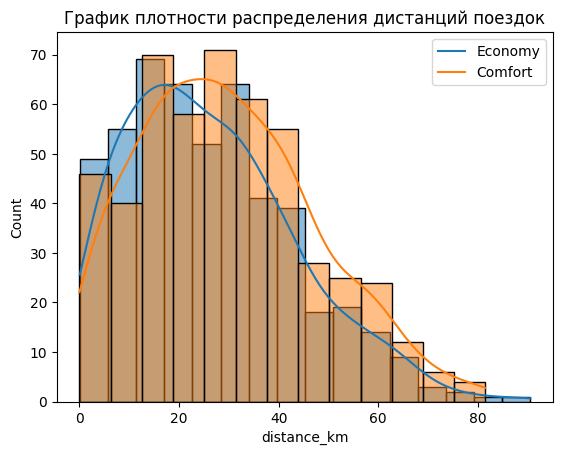

In [ ]:
sns.histplot(df_1['distance_km'], kde=True)
sns.histplot(df_2['distance_km'], kde=True)
plt.title('График плотности распределения дистанций поездок')
plt.legend(['Economy', 'Comfort'])
plt.show()

**Оба распределения визуально близки к логнормальному распределению и характеризуются выраженной правосторонней асимметрией (длинным "хвостом" в сторону больших дистанций).**

Подключение библиотеки статистических критериев и задание уровня значимости

In [ ]:
from scipy.stats import mannwhitneyu

# Уровень значимости
alpha = 0.05

Проведение теста Манна — Уитни (U-критерий Манна — Уитни)

Н0 - Для дальних поездок пользователи не имеют явных предпочтений между тарифами

H1 - На дальние поездки пользователи предпочитают Economy-классу более комфортные условия поездки в Comfort-классе

In [ ]:
result = mannwhitneyu(df_1['distance_km'], df_2['distance_km'], alternative='less')
print('p_value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
     print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p_value: 0.00064246
Отвергаем нулевую гипотезу


**Вывод**: в ходе анализа общего распределения дистанций (ср. значение = 26.28 км, медиана = 22.83 км) был применен односторонний критерий Манна-Уитни. Статистический тест подтвердил альтернативную гипотезу H1 ( 0.00064246 < 0.05). Это строго доказывает, что в масштабах всего сервиса распределение тарифа Comfort смещено в сторону более длинных дистанций по сравнению с тарифом Economy, то есть пользователи значимо чаще предпочитают Comfort-класс для поездок на дальние расстояния.